# Visualizing distributions of data

An early step in any effort to analyze or model data should be to understand how the variables are distributed. Techniques for distribution visualization can provide quick answers to many important questions.

1. What **range** do the observations cover?
2. What is their **central tendency**?
3. Are they heavily **skewed** in one direction?
4. Is there evidence for **bimodality**?
5. Are there significant **outliers**?
6. Do the answers to these questions vary **across subsets** defined by other variables?

By convention, the alias `sns` is used for `seaborn`:

In [ ]:
import seaborn as sns

Let's load smoe data and look at some plots possible with seaborn.

In [ ]:
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


The [distributions module](https://seaborn.pydata.org/api.html#distribution-api) contains several functions designed to answer questions such as these.

1. The **axes-level** functions are [`histplot()`](https://seaborn.pydata.org/generated/seaborn.histplot.html#seaborn.histplot), [`kdeplot()`](https://seaborn.pydata.org/generated/seaborn.kdeplot.html#seaborn.kdeplot), [`ecdfplot()`](https://seaborn.pydata.org/generated/seaborn.ecdfplot.html#seaborn.ecdfplot), and [`rugplot()`](https://seaborn.pydata.org/generated/seaborn.rugplot.html#seaborn.rugplot).
2. They are grouped together within the **figure-level** [`displot()`](https://seaborn.pydata.org/generated/seaborn.displot.html#seaborn.displot), [`jointplot()`](https://seaborn.pydata.org/generated/seaborn.jointplot.html#seaborn.jointplot), and [`pairplot()`](https://seaborn.pydata.org/generated/seaborn.pairplot.html#seaborn.pairplot) functions.

### Plotting univariate histograms

A **histogram** is a bar plot where the axis representing the data variable is divided into a set of discrete bins and the count of observations falling within each bin is shown using the height of the corresponding bar.

We use the `sns.displot()` function with the default value `kind="hist"`:

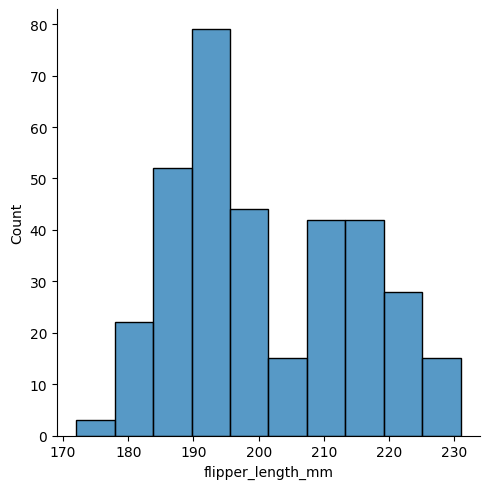

In [4]:
sns.displot(
    data=penguins,
    kind="hist",
    x="flipper_length_mm",
)

This plot immediately affords a few insights about the `flipper_length_mm` variable. For instance, we can see that the most common flipper length is about 195 mm, but the distribution appears bimodal, so this one number does not represent the data well.

**It is always advisable to check that your impressions of the distribution are consistent across different bin sizes**.

You may choose to adjust the size / number of bins in two ways:

- By Width: `binwidth=3`
- By Count: `bins=20`

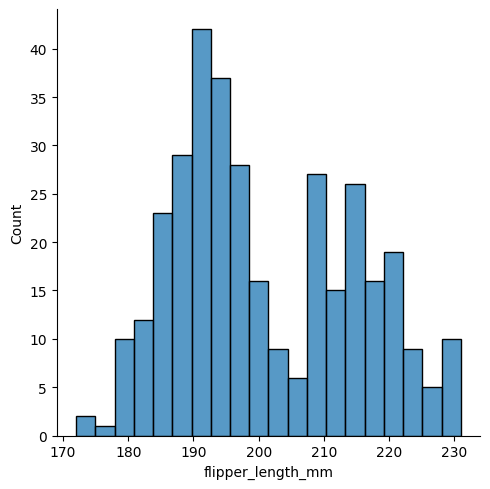

In [6]:
sns.displot(
    penguins,
    kind="hist",
    x="flipper_length_mm",
    binwidth=3
)

### Bar plot

It’s also possible to visualize the distribution of a categorical variable using the logic of a histogram.

In [30]:
tips = sns.load_dataset("tips")
tips['size'].value_counts().sort_index()

size
1      4
2    156
3     38
4     37
5      5
6      4
Name: count, dtype: int64

In the default case, the bin width may be too small, creating awkward gaps in the distribution. Hence either:

- specify the precise bin breaks by passing an array to bins: `bins=[1, 2, 3, 4, 5, 6, 7]`
- automatically specify them with: `discrete=True`
- discrete bins are automatically set for categorical variables, but it may also be helpful to “`shrink`” the bars slightly to emphasize the categorical nature of the axis:

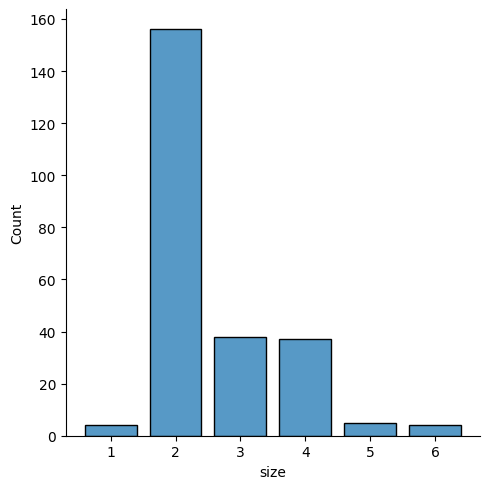

In [31]:
sns.displot(tips, x="size", discrete=True, shrink=0.8)

## Conditioning on other variables

Once you understand the distribution of a variable, the next step is often to ask: **whether features of that distribution differ across other variables in the dataset**. For example, what accounts for the bimodal distribution of flipper lengths that we saw above?

Assigning a variable to `hue` will draw a separate histogram for each of its unique values and distinguish them by color:

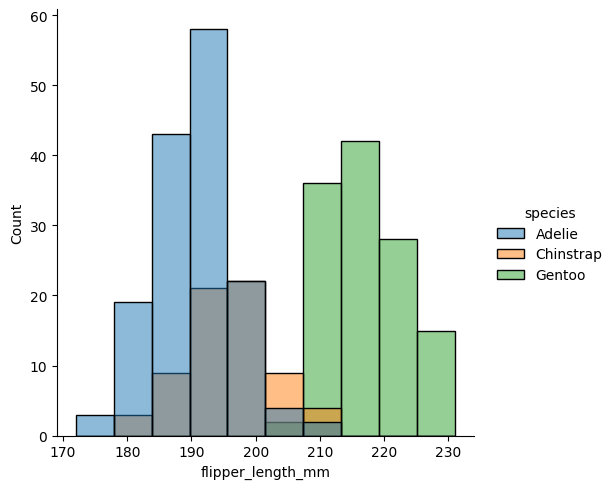

In [32]:
sns.displot(
    penguins,
    x="flipper_length_mm",
    hue="species"
)

By default, the different histograms are “layered” on top of each other and, in some cases, they may be difficult to distinguish. One option is to change the visual representation of the histogram from a bar plot to a “step” plot:

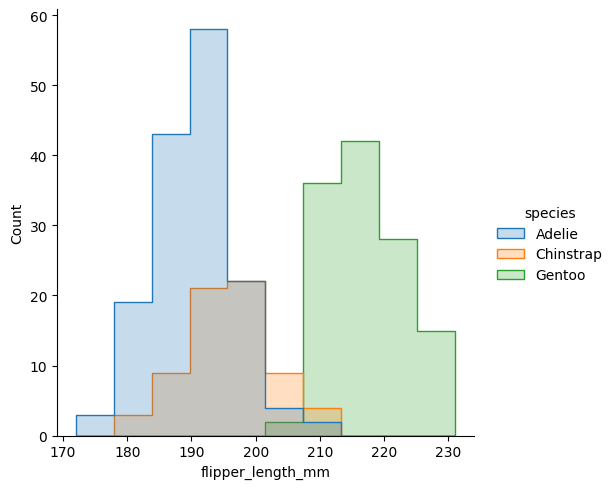

In [15]:
sns.displot(penguins, x="flipper_length_mm", hue="species", element="step")

Alternatively, instead of layering each bar, they can be “stacked”, or moved vertically. In this plot, the outline of the full histogram will match the plot with only a single variable:

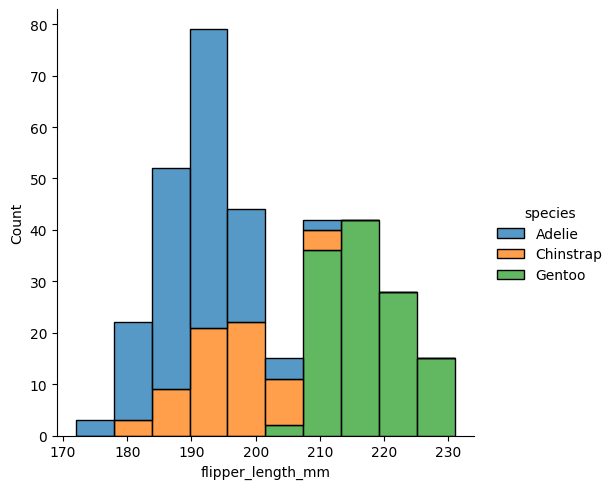

In [16]:
sns.displot(penguins, x="flipper_length_mm", hue="species", multiple="stack")

It is also possible to draw each individual distribution in a separate subplot: by assigning the second variable to `col` or `row` rather than (or in addition to) `hue`:

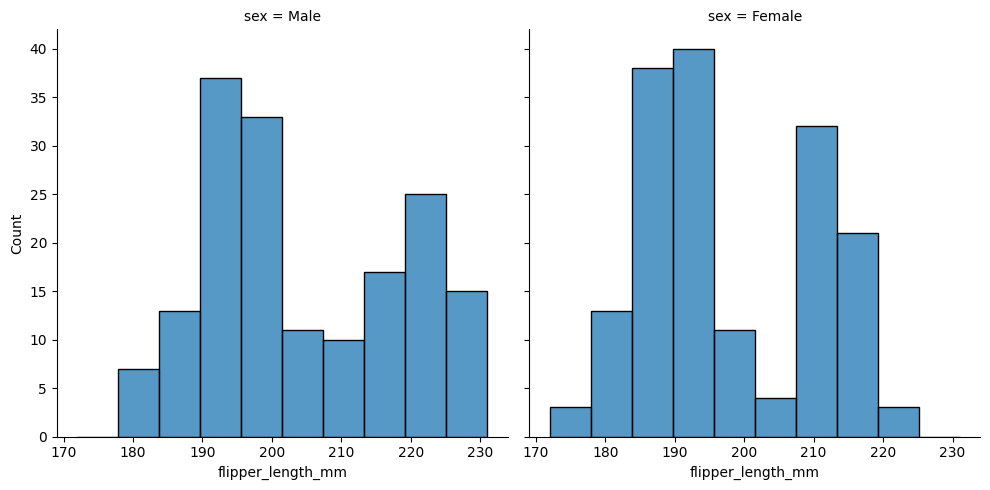

In [17]:
sns.displot(penguins, x="flipper_length_mm", col="sex")

::: {.callout-note}

Try replacing `col` with `row` or `hue`.

:::

None of these approaches are perfect, and we will soon see some alternatives to a histogram that are better-suited to the task of comparison.

## Normalized histogram statistics

- **When the subsets have unequal numbers of observations**, comparing their distributions in terms of counts may not be ideal.
- One solution is to normalize the counts using the `stat` parameter:

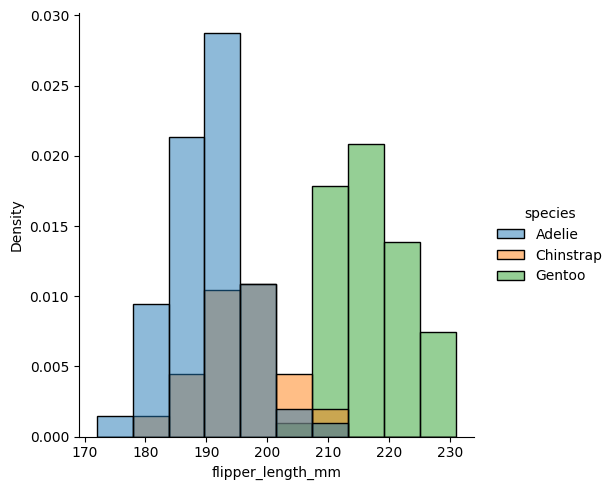

In [18]:
sns.displot(penguins, x="flipper_length_mm", hue="species", stat="density")

- By default, however, **the normalization is applied to the entire distribution**, so this simply rescales the height of the bars.
- By setting `common_norm=False`, **each subset will be normalized independently**

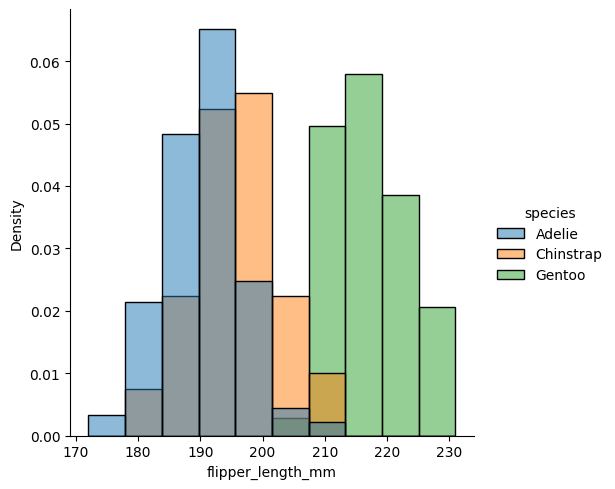

In [19]:
sns.displot(penguins, x="flipper_length_mm", hue="species", stat="density", common_norm=False)

- Density normalization scales the bars so that **their areas sum to 1**. As a result, the density axis is not directly interpretable.
- Another option is to normalize the bars so that **their heights sum to 1**. This makes most sense when the variable is discrete, but it is an option for all histograms:

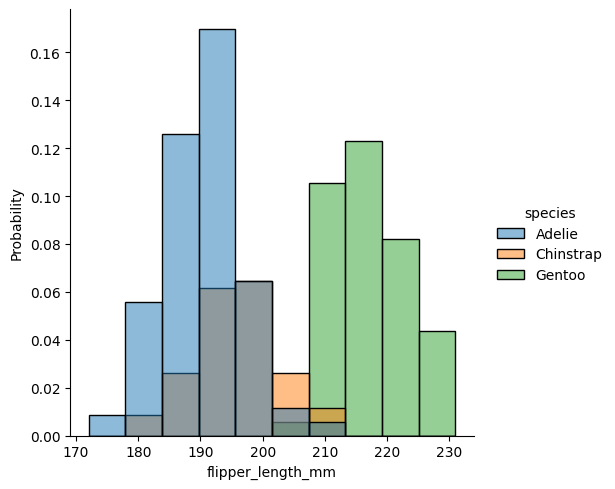

In [20]:
sns.displot(penguins, x="flipper_length_mm", hue="species", stat="probability")

## Kernel density estimation

A histogram aims to approximate the underlying probability density function that generated the data by binning and counting observations. Kernel density estimation (KDE) presents a different solution to the same problem. Rather than using discrete bins, a KDE plot smooths the observations with a Gaussian kernel, producing a continuous density estimate:

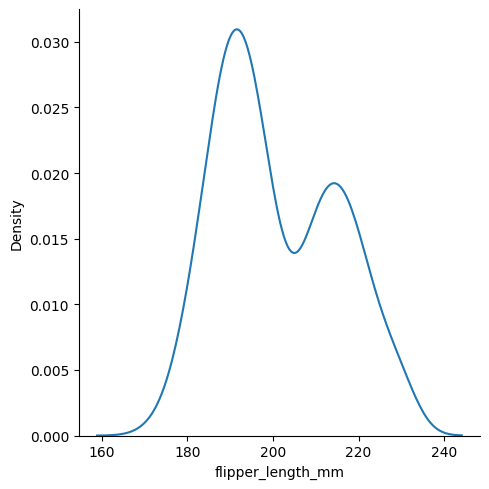

In [22]:
sns.displot(penguins, x="flipper_length_mm", kind="kde")

### Choosing the smoothing bandwidth

- Much like with the **bin size** in the histogram
- the ability of the KDE to accurately represent the data depends on the choice of **smoothing bandwidth**.
  
An over-smoothed estimate might erase meaningful features, but an under-smoothed estimate can obscure the true shape within random noise. The easiest way to check the robustness of the estimate is to adjust the default bandwidth:

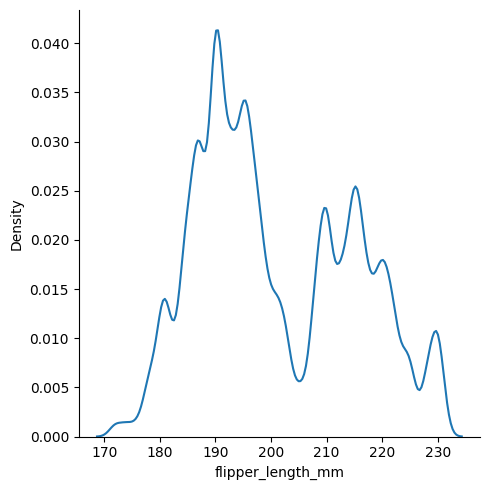

In [25]:
sns.displot(penguins, x="flipper_length_mm", kind="kde", bw_adjust=.25)

- Note how the **narrow** bandwidth makes the bimodality much more **apparent**, but the curve is much less smooth.
- In contrast, a **larger** bandwidth **obscures** the bimodality almost completely:

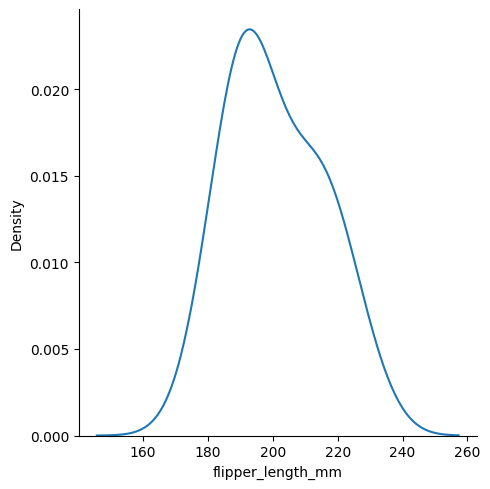

In [26]:
sns.displot(penguins, x="flipper_length_mm", kind="kde", bw_adjust=2)

## Empirical cumulative distributions

A third option for visualizing distributions computes the “empirical cumulative distribution function” (ECDF). This plot draws a monotonically-increasing curve through each datapoint such that **the height of the curve reflects the proportion of observations with a smaller value**:

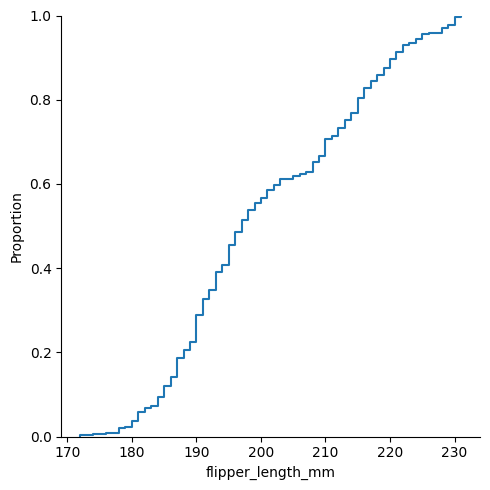

In [27]:
sns.displot(penguins, x="flipper_length_mm", kind="ecdf")

The ECDF plot has two key advantages.

Firstly, unlike the histogram or KDE, it directly represents each datapoint. That means there is no bin size or smoothing parameter to consider.

Secondly, because the curve is monotonically increasing, it is well-suited for comparing multiple distributions:

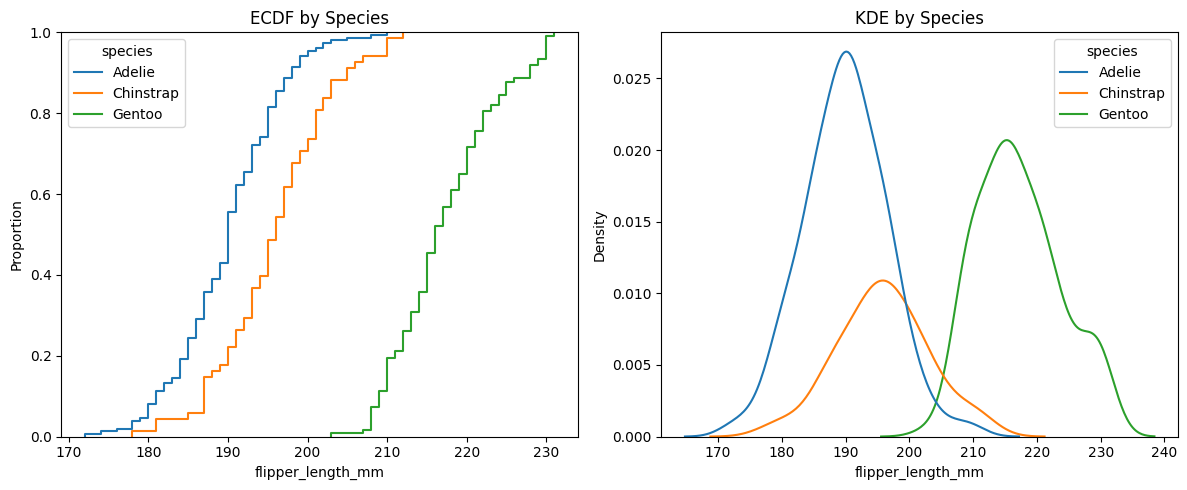

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.ecdfplot(data=penguins, x="flipper_length_mm", hue="species", ax=axes[0])
axes[0].set_title("ECDF by Species")

sns.kdeplot(data=penguins, x="flipper_length_mm", hue="species", ax=axes[1])
axes[1].set_title("KDE by Species")

plt.tight_layout()
plt.show()

The major downside to the ECDF plot is that it represents the shape of the distribution less intuitively than a histogram or density curve. Consider how the bimodality of flipper lengths is immediately apparent in the histogram, but to see it in the ECDF plot, you must look for varying slopes. **Nevertheless, with practice, you can learn to answer all of the important questions about a distribution by examining the ECDF, and doing so can be a powerful approach**.

## Visualizing bivariate distributions

- All of the examples so far have considered univariate distributions: distributions of a single variable, perhaps conditional on a second variable assigned to `hue`.
- Assigning a second variable to `y`, however, will plot a **bivariate distribution**
- To aid interpretation of the heatmap, add a `cbar=True` (colorbar) to show the mapping between counts and color intensity:

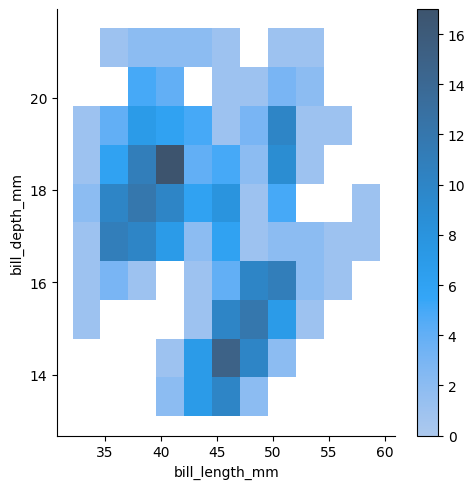

In [ ]:
sns.displot(penguins, x="bill_length_mm", y="bill_depth_mm", cbar=True)

A **bivariate histogram** bins the data within rectangles that tile the plot and then shows the count of observations within each rectangle with the fill color (analogous to a [`heatmap()`](https://seaborn.pydata.org/generated/seaborn.heatmap.html#seaborn.heatmap)).

Similarly, a **bivariate KDE** plot smoothes the (x, y) observations with a 2D Gaussian. The default representation then shows the contours of the 2D density:

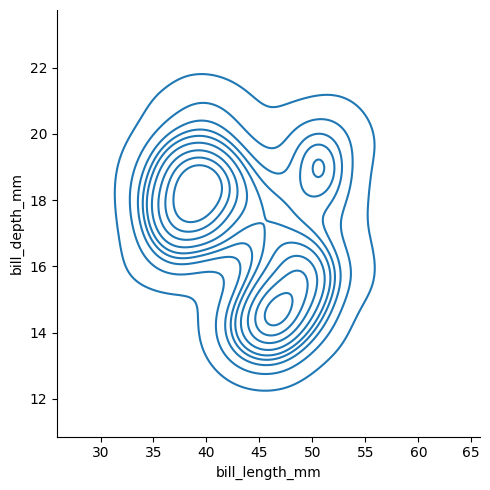

In [36]:
sns.displot(penguins, x="bill_length_mm", y="bill_depth_mm", kind="kde")

- Assigning a `hue` variable will plot multiple heatmaps or contour sets using different colors.
- For bivariate histograms, this will only work well if there is minimal overlap between the conditional distributions:

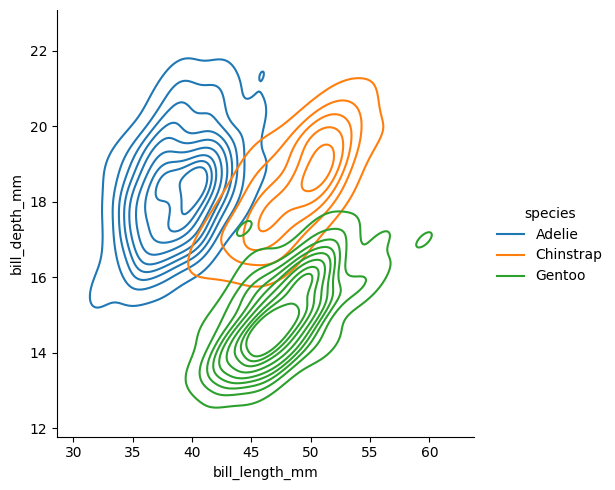

In [38]:
sns.displot(penguins, x="bill_length_mm", y="bill_depth_mm", hue="species", kind="kde")

### Bivariate Categorical Variables

In contrast, plotting two discrete variables is an easy to way show the cross-tabulation of the observations:

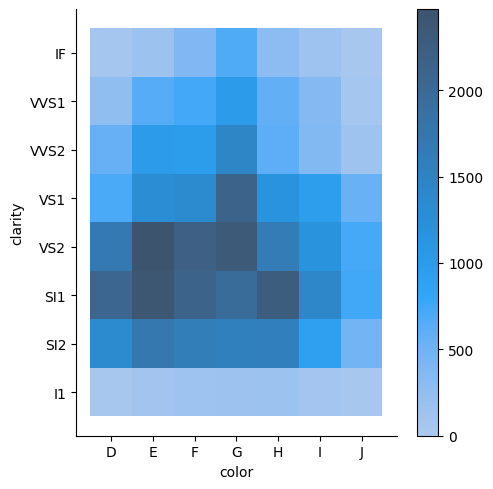

In [41]:
diamonds = sns.load_dataset("diamonds")
sns.displot(diamonds, x="color", y="clarity", cbar=True)

## Plotting joint and marginal distributions

- The first is `jointplot()`, which augments a bivariate relational or distribution plot with the marginal distributions of the two variables.
- By default, `jointplot()` represents the bivariate distribution using `scatterplot()` and the marginal distributions using `histplot()`:

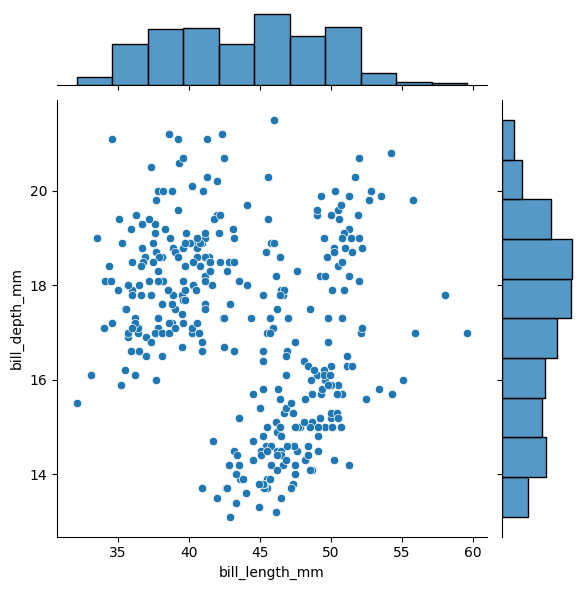

In [42]:
sns.jointplot(data=penguins, x="bill_length_mm", y="bill_depth_mm")

Similar to `displot()`, setting a different `kind="kde"` in `jointplot()` will change both the joint and marginal plots the use `kdeplot()`:

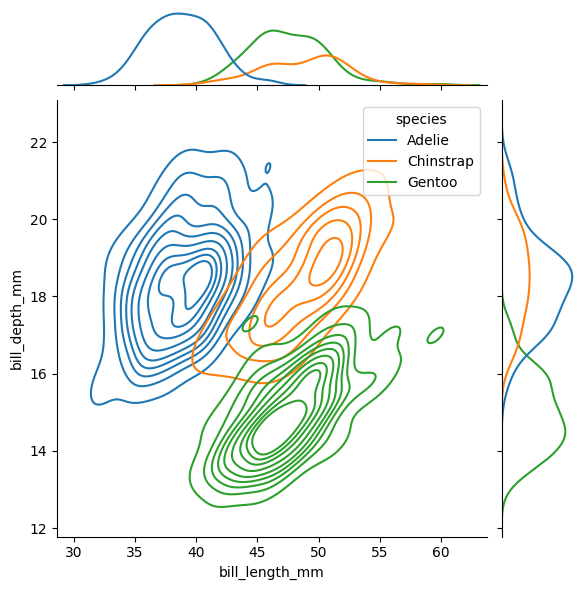

In [43]:
sns.jointplot(
    data=penguins,
    x="bill_length_mm", y="bill_depth_mm", hue="species",
    kind="kde"
)

[`jointplot()`](https://seaborn.pydata.org/generated/seaborn.jointplot.html#seaborn.jointplot) is a convenient interface to the [**`JointGrid`**](https://seaborn.pydata.org/generated/seaborn.JointGrid.html#seaborn.JointGrid) class, which offeres more flexibility when used directly:

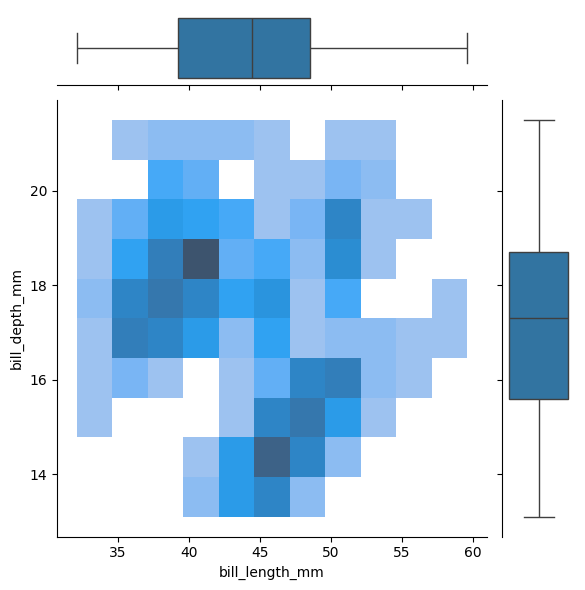

In [44]:
g = sns.JointGrid(data=penguins, x="bill_length_mm", y="bill_depth_mm")
g.plot_joint(sns.histplot)
g.plot_marginals(sns.boxplot)

A less-obtrusive way to show marginal distributions uses a “rug” plot, which adds a small tick on the edge of the plot to represent each individual observation. This is built into displot():

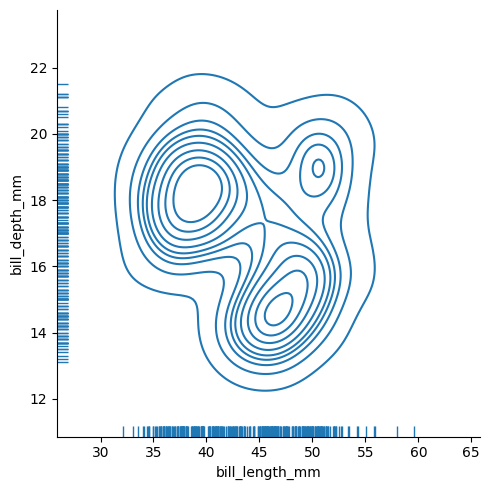

In [45]:
sns.displot(
    penguins, x="bill_length_mm", y="bill_depth_mm",
    kind="kde", rug=True
)

And the axes-level [`rugplot()`](https://seaborn.pydata.org/generated/seaborn.rugplot.html#seaborn.rugplot) function can be used to add rugs on the side of any other kind of plot:

<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

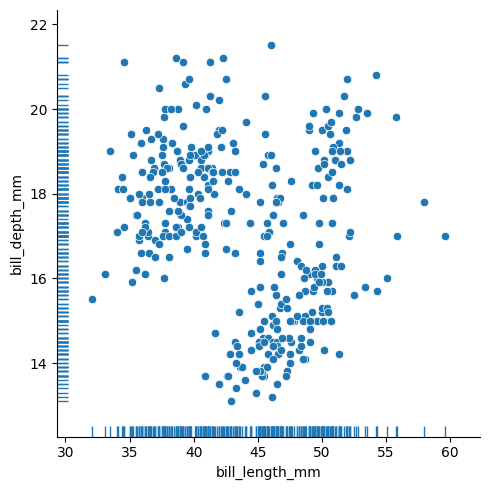

In [46]:
sns.relplot(data=penguins, x="bill_length_mm", y="bill_depth_mm")
sns.rugplot(data=penguins, x="bill_length_mm", y="bill_depth_mm")

## Plotting many distributions

The `pairplot()` function offers a similar blend of joint and marginal distributions. Rather than focusing on a single relationship, however, `pairplot()` uses a [“small-multiple” approach](https://seaborn.pydata.org/tutorial/axis_grids.html) to visualize:

1. the **univariate distribution** of all variables in a dataset
2. along with all of their **pairwise relationships**:

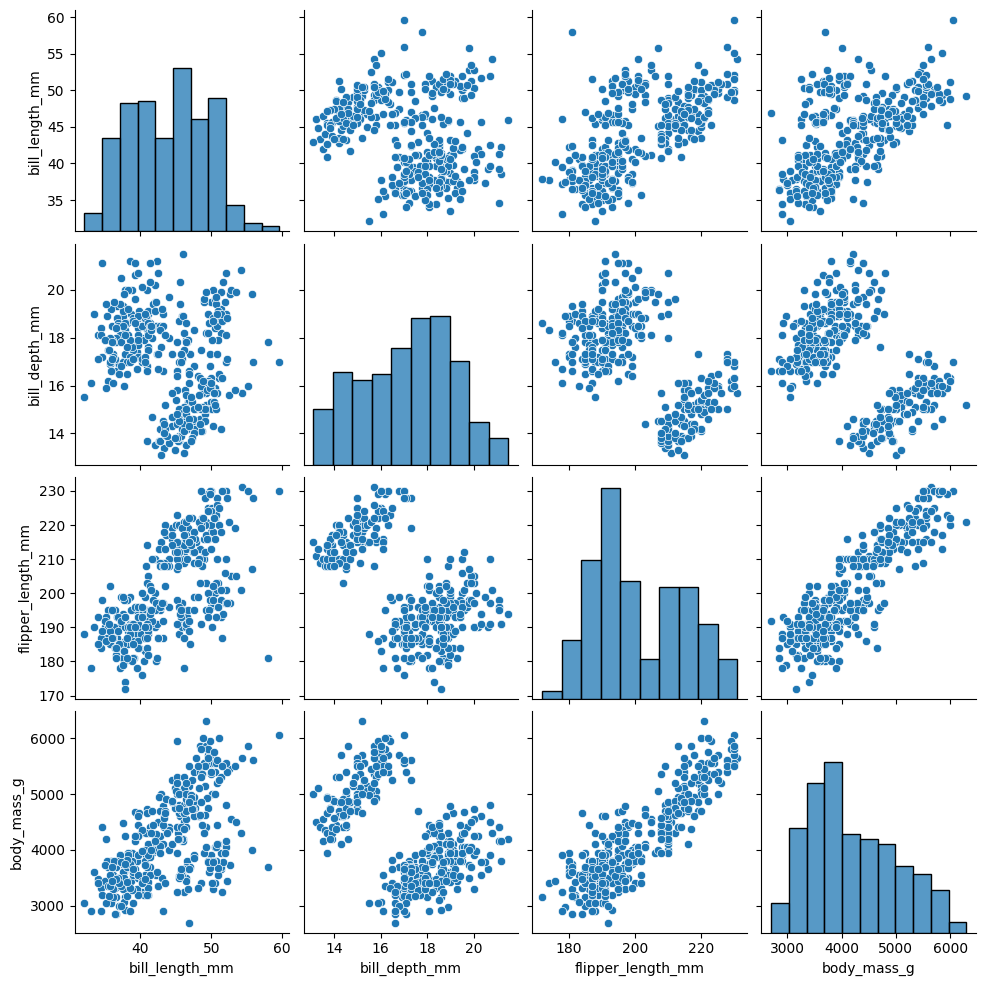

In [47]:
sns.pairplot(penguins)

As with [`jointplot()`](https://seaborn.pydata.org/generated/seaborn.jointplot.html#seaborn.jointplot)/[**JointGrid**](https://seaborn.pydata.org/generated/seaborn.JointGrid.html#seaborn.JointGrid), using the underlying [**PairGrid**](https://seaborn.pydata.org/generated/seaborn.PairGrid.html#seaborn.PairGrid) directly will afford more flexibility with only a bit more typing:

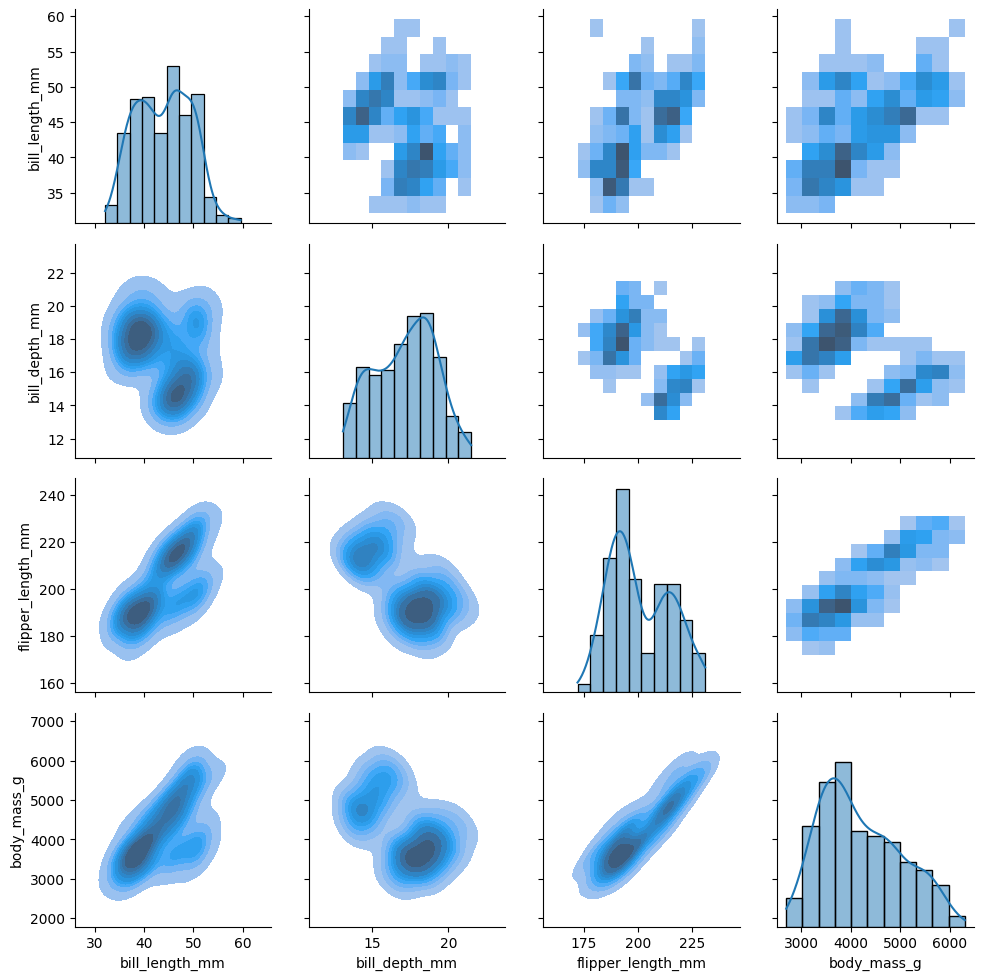

In [48]:
g = sns.PairGrid(penguins)
g.map_upper(sns.histplot)
g.map_lower(sns.kdeplot, fill=True)
g.map_diag(sns.histplot, kde=True)